# L3 Photonic Crystal Cavity — Convergence Tests

Numerical convergence tests for the GME simulation parameters.
Also includes a row-number sweep (varying Ny at fixed Nx) to characterize
in-plane vs out-of-plane Q decomposition.

In [8]:
import legume
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
# ── Physical parameters ──────────────────────────────────────────
a_nm = 250              # lattice constant in nm
ra = 75 / a_nm          # hole radius in units of a (r/a = 0.3)
dslab = 170 / a_nm      # slab thickness in units of a (d/a = 0.68)
n_slab = 3.46           # refractive index (GaAs at 970 nm)

In [10]:
# ── Band structure of the perfect PhC (unit cell) ──────────────────
lattice_unit = legume.Lattice('hexagonal')
phc_unit = legume.PhotCryst(lattice_unit)
phc_unit.add_layer(d=dslab, eps_b=n_slab**2)
phc_unit.add_shape(legume.Circle(x_cent=0, y_cent=0, r=ra))

path_dict = lattice_unit.bz_path(['G', 'M', 'K', 'G'], [40, 40, 40])
kpoints = path_dict['kpoints']

gme_bands = legume.GuidedModeExp(phc_unit, gmax=3.0, truncate_g='tbt')
gme_bands.run(kpoints=kpoints, gmode_inds=[0], verbose=False, numeig=10)

# Find the largest complete bandgap
freqs_b = gme_bands.freqs
f_lb, f_ub, f_target = None, None, None
best_gap = 0
for i in range(freqs_b.shape[1] - 1):
    top = np.max(freqs_b[:, i])
    bot = np.min(freqs_b[:, i + 1])
    if bot > top and (bot - top) > best_gap:
        best_gap = bot - top
        f_lb, f_ub = top, bot
        f_target = (top + bot) / 2

print(f"Bandgap: {f_lb:.6f} – {f_ub:.6f}")
print(f"Centre (f_target): {f_target:.6f}")
print(f"Gap width: {f_ub - f_lb:.6f}")

Bandgap: 0.248947 – 0.327450
Centre (f_target): 0.288198
Gap width: 0.078503


## Design Definitions

Three L3 cavity optimization levels used throughout the convergence tests.

In [11]:
# ── Design shift definitions ──────────────────────────────────────
shifts_none = None                                              # unoptimized
shifts_1h   = [(0, 0.17964)]                                    # 1-hole (dx1 = 0.17964a)
shifts_3h   = [(0, 0.27239), (1, 0.21982), (2, 0.00000)]       # 3-hole

print("Designs defined:")
print(f"  Unoptimized: no shifts")
print(f"  1-hole: dx1 = 0.17964a ({0.17964*a_nm:.1f} nm)")
print(f"  3-hole: dx1 = 0.27239a, dx2 = 0.21982a, dx3 = 0.0a")

Designs defined:
  Unoptimized: no shifts
  1-hole: dx1 = 0.17964a (44.9 nm)
  3-hole: dx1 = 0.27239a, dx2 = 0.21982a, dx3 = 0.0a


In [12]:
def run_convergence_test(Nx_t, Ny_t, gmax_t, numeig_t, gmode_inds_t,
                         ra_t=ra, dslab_t=dslab, n_slab_t=n_slab,
                         f_target_t=f_target, f_lb_t=f_lb, f_ub_t=f_ub,
                         shifts=None, f_ref=None,
                         truncate_g='tbt', gmode_step=1e-2):
    """Run a single L3 cavity simulation and return (Q, freq, npw).

    eig_sigma is always f_target_t (bandgap centre) — f_ref is only for mode ID.
    Returns (None, None, 0) on any error so sweeps continue gracefully.
    """
    try:
        lat = legume.Lattice([Nx_t, 0], [0, Ny_t * np.sqrt(3) / 2])

        xp_t, yp_t = [], []
        nx_t, ny_t = Nx_t // 2 + 1, Ny_t // 2 + 1
        for iy in range(ny_t):
            for ix in range(nx_t):
                if iy == 0 and ix in (0, 1):
                    continue
                xp_t.append(ix + (iy % 2) * 0.5)
                yp_t.append(iy * np.sqrt(3) / 2)

        dx_t = [0.0] * len(xp_t)
        if shifts is not None:
            for (ic, dx_val) in shifts:
                if ic < len(dx_t):
                    dx_t[ic] = dx_val

        phc = legume.PhotCryst(lat)
        phc.add_layer(d=dslab_t, eps_b=n_slab_t**2)
        for ic, x in enumerate(xp_t):
            yc = yp_t[ic]
            xc = x if x == 0 else x + dx_t[ic]
            phc.add_shape(legume.Circle(x_cent=xc, y_cent=yc, r=ra_t))
            if nx_t - 0.6 > xp_t[ic] > 0 and (ny_t - 1.1) * np.sqrt(3) / 2 > yp_t[ic] > 0:
                phc.add_shape(legume.Circle(x_cent=-xc, y_cent=-yc, r=ra_t))
            if nx_t - 1.6 > xp_t[ic] > 0:
                phc.add_shape(legume.Circle(x_cent=-xc, y_cent=yc, r=ra_t))
            if (ny_t - 1.1) * np.sqrt(3) / 2 > yp_t[ic] > 0 and nx_t - 1.1 > xp_t[ic]:
                phc.add_shape(legume.Circle(x_cent=xc, y_cent=-yc, r=ra_t))

        # eig_sigma always at bandgap centre — f_ref is only used for mode identification
        gme_t = legume.GuidedModeExp(phc, gmax=gmax_t, truncate_g=truncate_g)
        gme_t.run(kpoints=np.array([[0], [0]]),
                  gmode_inds=gmode_inds_t, verbose=False,
                  numeig=numeig_t, eig_sigma=f_target_t,
                  compute_im=False, gradients='approx',
                  gmode_step=gmode_step)

        npw = gme_t.gvec.shape[1]
        all_freqs = gme_t.freqs[0, :]

        if f_ref is not None:
            best_idx, best_dist = None, float('inf')
            for i in range(len(all_freqs)):
                fi = float(all_freqs[i])
                if f_lb_t < fi < f_ub_t:
                    dist = abs(fi - f_ref)
                    if dist < best_dist:
                        best_dist, best_idx = dist, i
        else:
            best_idx = None
            for i in range(len(all_freqs)):
                if f_lb_t < float(all_freqs[i]) < f_ub_t:
                    best_idx = i
                    break

        if best_idx is None:
            return (None, None, npw)

        (freq_im, _, _) = gme_t.compute_rad(0, [best_idx])
        if float(freq_im[0]) <= 0:
            return (None, float(all_freqs[best_idx]), npw)
        Q_t = float(all_freqs[best_idx]) / (2 * float(freq_im[0]))
        return (Q_t, float(all_freqs[best_idx]), npw)

    except Exception as exc:
        print(f"    [WARNING] run_convergence_test({Nx_t},{Ny_t},gmax={gmax_t},ne={numeig_t}) failed: {exc}")
        return (None, None, 0)

print("Convergence test helper defined.")

Convergence test helper defined.


In [16]:
import os
from datetime import datetime

DESIGNS = {
    'none':  (shifts_none, 'Unoptimized'),
    '1hole': (shifts_1h,   '1-hole'),
    '3hole': (shifts_3h,   '3-hole'),
}

def save_sweep(design_tag, sweep_name, values, results):
    """Save sweep results to data/<timestamp>_<design>_<sweep>/."""
    timestamp = datetime.now().strftime('%Y-%m-%d_%H%M%S')
    folder = os.path.join('data', f'{timestamp}_{design_tag}_{sweep_name}')
    os.makedirs(folder, exist_ok=True)
    Qs    = np.array([(r[0] if r[0] is not None else np.nan) for r in results])
    freqs = np.array([(r[1] if r[1] is not None else np.nan) for r in results])
    npws  = np.array([r[2] for r in results])
    np.save(os.path.join(folder, 'Qs.npy'), Qs)
    np.save(os.path.join(folder, 'freqs.npy'), freqs)
    np.save(os.path.join(folder, 'npws.npy'), npws)
    np.save(os.path.join(folder, 'values.npy'),
            np.array(values, dtype=object), allow_pickle=True)
    with open(os.path.join(folder, 'info.txt'), 'w') as fout:
        fout.write(f'Sweep: {sweep_name}\n')
        fout.write(f'Design: {design_tag}\n')
        fout.write(f'Values: {values}\n')
        fout.write(f'Timestamp: {timestamp}\n')
    print(f"    Saved -> {folder}/")
    return folder

def run_sweep_for_design(label, run_fn, values):
    print(f"\n  {label}")
    print(f"    {'Value':>16s}  {'npw':>6s}  {'Q':>14s}  {'freq':>10s}")
    print("    " + "-" * 50)
    results = []
    for v in values:
        Q, f, npw = run_fn(v)
        results.append((Q, f, npw))
        if Q is not None:
            print(f"    {str(v):>16s}  {npw:6d}  {Q:14.1f}  {f:10.5f}")
        else:
            print(f"    {str(v):>16s}  {npw:6d}  {'N/A':>14s}  {'N/A':>10s}")
    return results

# Compute reference cavity frequencies once, cached for all sweeps
print("Computing reference cavity frequencies...")
F_REFS = {}
for tag, (shifts, label) in DESIGNS.items():
    Q_ref, f_ref, _ = run_convergence_test(16, 10, 2.0, 10, [0], shifts=shifts)
    F_REFS[tag] = f_ref
    if f_ref is not None:
        print(f"  {label:>12s}: Q_ref = {Q_ref:,.0f}, f_ref = {f_ref:.6f}")
    else:
        print(f"  {label:>12s}: NO CAVITY MODE FOUND")

print("\nHelpers ready.")


import glob

def load_latest_sweep(design_tag, sweep_name):
    """Find newest data/<timestamp>_<design>_<sweep>/ and load its contents."""
    pattern = os.path.join('data', f'*_{design_tag}_{sweep_name}')
    folders = sorted(glob.glob(pattern))
    if not folders:
        return None
    folder = folders[-1]
    return {
        'folder': folder,
        'Qs':     np.load(os.path.join(folder, 'Qs.npy')),
        'freqs':  np.load(os.path.join(folder, 'freqs.npy')),
        'npws':   np.load(os.path.join(folder, 'npws.npy')),
        'values': np.load(os.path.join(folder, 'values.npy'), allow_pickle=True),
    }

# Consistent colour palette across all sweeps (plasma colormap)
DESIGN_COLORS = {
    'none':  plt.cm.plasma(0.15),
    '1hole': plt.cm.plasma(0.50),
    '3hole': plt.cm.plasma(0.82),
}

def plot_sweep(sweep_name, xlabel, title, categorical=False, x_tick_labels=None):
    """Load saved data for all 3 designs and plot Q, freq, and relative convergence."""
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
    axQ, axF, axC = axes

    for tag, (_, label) in DESIGNS.items():
        data = load_latest_sweep(tag, sweep_name)
        if data is None:
            print(f"  [skip] no saved data for {tag} / {sweep_name}")
            continue
        vals = data['values']
        Qs    = data['Qs']
        freqs = data['freqs']
        xs = np.arange(len(vals)) if categorical else np.array([float(v) for v in vals])
        color = DESIGN_COLORS[tag]

        axQ.plot(xs, Qs,    'o-', color=color, lw=2, ms=7, label=label)
        axF.plot(xs, freqs, 's-', color=color, lw=2, ms=7, label=label)

        # Relative change between consecutive valid points (%)
        valid = [(xs[i], Qs[i], freqs[i]) for i in range(len(xs))
                 if not np.isnan(Qs[i]) and not np.isnan(freqs[i])]
        if len(valid) >= 2:
            xc  = [valid[i][0] for i in range(1, len(valid))]
            dQ  = [abs(valid[i][1] - valid[i-1][1]) / abs(valid[i-1][1]) * 100
                   for i in range(1, len(valid))]
            axC.plot(xc, dQ, 'D--', color=color, lw=1.5, ms=6, label=label)

    if categorical and x_tick_labels is not None:
        for ax in (axQ, axF, axC):
            ax.set_xticks(range(len(x_tick_labels)))
            ax.set_xticklabels(x_tick_labels, fontsize=9)
        # convergence x-axis: mid-points are indices 1..n
        axC.set_xticks(range(1, len(x_tick_labels)))
        axC.set_xticklabels(x_tick_labels[1:], fontsize=9)

    axQ.set_xlabel(xlabel, fontsize=12); axQ.set_ylabel('Q factor', fontsize=12)
    axQ.set_title('(a) Q factor', fontsize=12)
    axQ.grid(alpha=0.3); axQ.legend(fontsize=10)

    axF.set_xlabel(xlabel, fontsize=12); axF.set_ylabel('Frequency (c/a)', fontsize=12)
    axF.set_title('(b) Frequency', fontsize=12)
    axF.grid(alpha=0.3); axF.legend(fontsize=10)

    axC.axhline(1.0, color='gray', lw=1, ls='--', label='1 % threshold')
    axC.set_yscale('log')
    axC.set_xlabel(xlabel, fontsize=12); axC.set_ylabel('Relative ΔQ (%)', fontsize=12)
    axC.set_title('(c) Q convergence (step-to-step, log)', fontsize=12)
    axC.grid(alpha=0.3, which='both'); axC.legend(fontsize=10)

    fig.suptitle(title, fontsize=13)
    fig.tight_layout()
    plt.show()

print("Loader and plotter ready.")

Computing reference cavity frequencies...
   Unoptimized: Q_ref = 6,344, f_ref = 0.259656
        1-hole: Q_ref = 198,852, f_ref = 0.257539
        3-hole: Q_ref = 1,438,926, f_ref = 0.256908

Helpers ready.
Loader and plotter ready.


## Convergence Tests — All Designs

In [ ]:
# --- FAQ Step 1: gmax sweep ---
gmax_vals = [1.5, 2.0, 2.5, 3.0, 4, 6]
for tag, (shifts, label) in DESIGNS.items():
    f_ref = F_REFS[tag]
    results = run_sweep_for_design(label,
        lambda gm, s=shifts, fr=f_ref: run_convergence_test(16, 10, gm, 10, [0], shifts=s, f_ref=fr),
        gmax_vals)
    save_sweep(tag, 'gmax', gmax_vals, results)


  Unoptimized
               Value     npw               Q        freq
    --------------------------------------------------
                 1.5    1225          6120.9     0.25880
                 2.0    2275          6343.7     0.25966
                 2.5    3483          6595.9     0.26007
                 3.0    4947          6720.6     0.26036


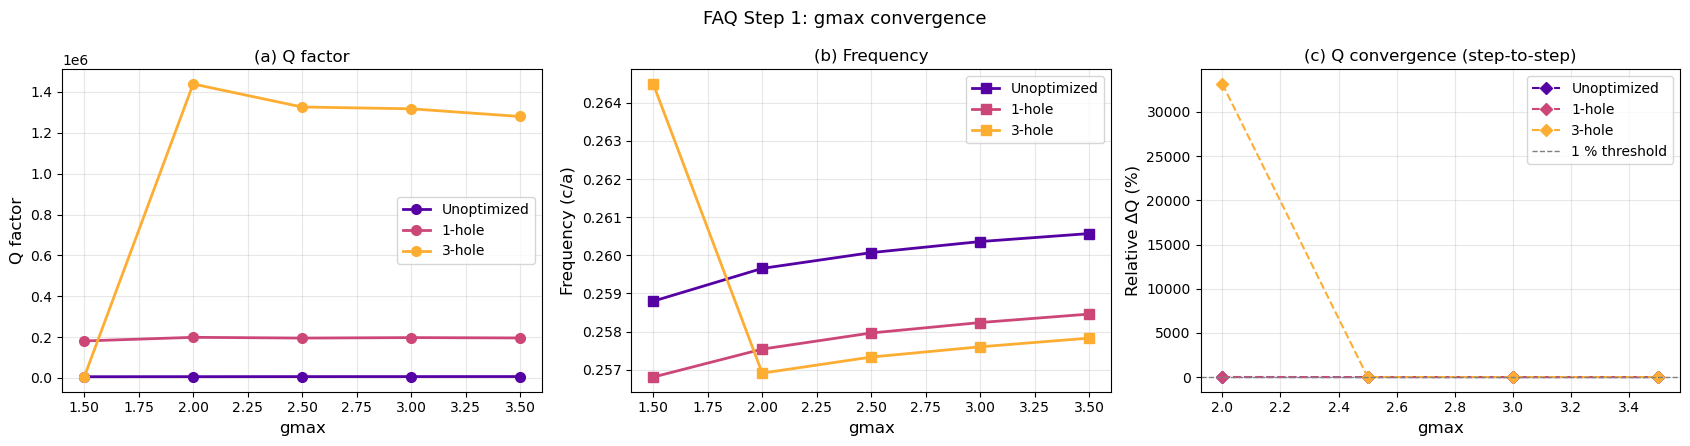

In [17]:
# --- Plot Step 1: gmax ---
plot_sweep('gmax', xlabel='gmax', title='FAQ Step 1: gmax convergence')

In [ ]:
# --- FAQ Step 2: gmode_inds sweep (at gmax = 3.5) ---
gmode_configs = [[0], [0, 1], [0, 2], [0, 4]]
best_gmax = 3
for tag, (shifts, label) in DESIGNS.items():
    f_ref = F_REFS[tag]
    results = run_sweep_for_design(label,
        lambda gi, s=shifts, fr=f_ref: run_convergence_test(16, 10, best_gmax, 10, gi, shifts=s, f_ref=fr),
        gmode_configs)
    save_sweep(tag, 'gmode_inds', gmode_configs, results)


  Unoptimized
               Value     npw               Q        freq
    --------------------------------------------------
                 [0]    6893          6845.1     0.26057


In [ ]:
# --- Plot Step 2: gmode_inds ---
gmode_labels = ['[0]', '[0,1]', '[0,1,2]']
plot_sweep('gmode_inds', xlabel='gmode_inds', title='FAQ Step 2: gmode_inds convergence',
           categorical=True, x_tick_labels=gmode_labels)

In [ ]:
# --- FAQ Step 3: gmax recheck with gmode_inds = [0, 1] ---
gmax_vals_rc = [1.5, 2.0, 2.5, 3.0, 3.5]
best_gmode = [0, 1]
for tag, (shifts, label) in DESIGNS.items():
    f_ref = F_REFS[tag]
    results = run_sweep_for_design(label,
        lambda gm, s=shifts, fr=f_ref: run_convergence_test(16, 10, gm, 10, best_gmode, shifts=s, f_ref=fr),
        gmax_vals_rc)
    save_sweep(tag, 'gmax_recheck', gmax_vals_rc, results)

In [ ]:
# --- Plot Step 3: gmax recheck ---
plot_sweep('gmax_recheck', xlabel='gmax', title='FAQ Step 3: gmax recheck (gmode_inds=[0,1,2])')

In [ ]:
# --- Supercell size sweep ---
sc_sizes = [(8, 6), (12, 8), (16, 10), (20, 12), (24, 14), (28, 16), (32, 18)]
for tag, (shifts, label) in DESIGNS.items():
    f_ref = F_REFS[tag]
    results = run_sweep_for_design(label,
        lambda sc, s=shifts, fr=f_ref: run_convergence_test(sc[0], sc[1], 2.0, 10, [0], shifts=s, f_ref=fr),
        sc_sizes)
    save_sweep(tag, 'supercell', sc_sizes, results)

In [ ]:
# --- Plot Supercell ---
sc_labels = ['(8,6)', '(12,8)', '(16,10)', '(20,12)', '(24,14)', '(28,16)', '(32,18)']
plot_sweep('supercell', xlabel='supercell (Nx,Ny)', title='Supercell size convergence',
           categorical=True, x_tick_labels=sc_labels)

In [ ]:
# --- numeig sweep ---
numeig_vals = [6, 8, 10, 12, 15, 20]
for tag, (shifts, label) in DESIGNS.items():
    f_ref = F_REFS[tag]
    results = run_sweep_for_design(label,
        lambda ne, s=shifts, fr=f_ref: run_convergence_test(16, 10, 2.0, ne, [0], shifts=s, f_ref=fr),
        numeig_vals)
    save_sweep(tag, 'numeig', numeig_vals, results)

In [ ]:
# --- Plot numeig ---
plot_sweep('numeig', xlabel='numeig', title='numeig convergence')

## Row-Number Sweep (Ny only, Nx = 16 fixed)

This sweep varies only the number of PhC mirror rows (Ny) while keeping
Nx = 16 fixed. This measures how Q saturates as more mirror rows are added,
allowing decomposition into $Q_\perp$ (out-of-plane) and $Q_\parallel$ (in-plane):

$$\frac{1}{Q_\text{total}} = \frac{1}{Q_\perp} + \frac{1}{Q_\parallel(N_y)}$$

Note: only even Ny values work with a triangular lattice (odd Ny breaks periodicity).

In [ ]:
import os
from datetime import datetime

Nx_fixed = 16
Ny_values = [6, 8, 10, 12, 14, 16]

designs = {
    '1-hole': shifts_1h,
    '3-hole': shifts_3h,
}

for design_name, shifts in designs.items():
    print(f"\n{'='*50}")
    print(f"  Row sweep: {design_name}")
    print(f"{'='*50}")

    # Reference run to get f_ref
    ref_Q, ref_f, _ = run_convergence_test(16, 10, 2.0, 10, [0], shifts=shifts)
    print(f"  Reference: Q = {ref_Q:,.0f}, f = {ref_f:.6f}")

    Qs, freqs = [], []
    print(f"  {'Ny':>4s}  {'Rows':>5s}  {'Q':>12s}  {'freq':>10s}")
    print("  " + "-" * 36)

    for Ny_val in Ny_values:
        Q, f, _ = run_convergence_test(Nx_fixed, Ny_val, 2.0, 10, [0],
                                        shifts=shifts, f_ref=ref_f)
        Qs.append(Q if Q is not None else 0)
        freqs.append(f if f is not None else 0)
        rows_each_side = Ny_val // 2  # mirror rows on each side of cavity
        if Q is not None:
            print(f"  {Ny_val:4d}  {rows_each_side:5d}  {Q:12,.0f}  {f:10.6f}")
        else:
            print(f"  {Ny_val:4d}  {rows_each_side:5d}  {'N/A':>12s}  {'N/A':>10s}")

    Qs = np.array(Qs)
    freqs = np.array(freqs)

    # Save data
    timestamp = datetime.now().strftime('%Y-%m-%d_%H%M%S')
    tag = design_name.replace('-', '')
    folder = os.path.join('data', f'{timestamp}_{tag}_row_sweep')
    os.makedirs(folder, exist_ok=True)
    np.save(os.path.join(folder, 'Qs.npy'), Qs)
    np.save(os.path.join(folder, 'freqs.npy'), freqs)
    np.save(os.path.join(folder, 'Ny_values.npy'), np.array(Ny_values))
    with open(os.path.join(folder, 'info.txt'), 'w') as fout:
        fout.write(f'Sweep: {tag}_row_sweep\n')
        fout.write(f'Date: {timestamp}\n\n')
        fout.write(f'--- Physical parameters ---\n')
        fout.write(f'a_nm = {a_nm}\n')
        fout.write(f'ra = {ra:.4f} ({ra*a_nm:.1f} nm)\n')
        fout.write(f'dslab = {dslab:.4f} ({dslab*a_nm:.1f} nm)\n')
        fout.write(f'n_slab = {n_slab}\n\n')
        fout.write(f'--- Sweep ---\n')
        fout.write(f'Nx = {Nx_fixed} (fixed)\n')
        fout.write(f'Ny_values = {Ny_values}\n')
        fout.write(f'Design: {design_name}\n')
        fout.write(f'Shifts: {shifts}\n')
    print(f"  Saved to {folder}/")


  Row sweep: 1-hole
  Reference: Q = 198,852, f = 0.257539
    Ny   Rows             Q        freq
  ------------------------------------
     6      3       116,633    0.257658
     8      4       163,194    0.257522
    10      5       198,852    0.257539
  Saved to data/2026-04-17_094737_1hole_row_sweep/

  Row sweep: 3-hole
  Reference: Q = 1,438,926, f = 0.256908
    Ny   Rows             Q        freq
  ------------------------------------
     6      3       762,349    0.257011
     8      4     1,152,274    0.256890
    10      5     1,438,926    0.256908
  Saved to data/2026-04-17_094808_3hole_row_sweep/


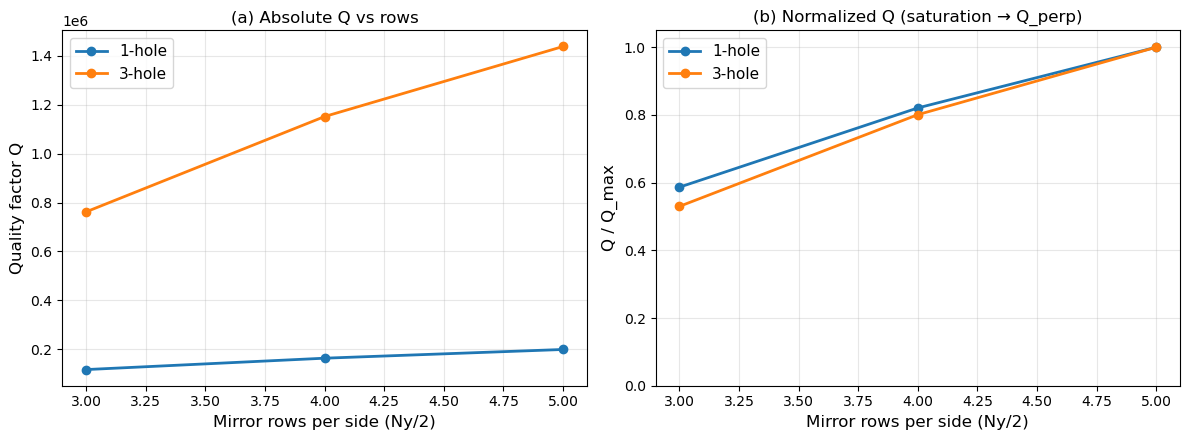

In [ ]:
# Plot row sweep results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

for design_name, shifts in designs.items():
    # Re-run (or load from saved data)
    ref_Q, ref_f, _ = run_convergence_test(16, 10, 2.0, 10, [0], shifts=shifts)
    Qs = []
    for Ny_val in Ny_values:
        Q, f, _ = run_convergence_test(Nx_fixed, Ny_val, 2.0, 10, [0],
                                        shifts=shifts, f_ref=ref_f)
        Qs.append(Q if Q is not None else 0)

    rows = [Ny // 2 for Ny in Ny_values]
    ax1.plot(rows, Qs, 'o-', lw=2, markersize=6, label=design_name)
    ax2.plot(rows, np.array(Qs) / max(Qs), 'o-', lw=2, markersize=6, label=design_name)

ax1.set_xlabel('Mirror rows per side (Ny/2)', fontsize=12)
ax1.set_ylabel('Quality factor Q', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)
ax1.set_title('(a) Absolute Q vs rows')

ax2.set_xlabel('Mirror rows per side (Ny/2)', fontsize=12)
ax2.set_ylabel('Q / Q_max', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)
ax2.set_ylim(0, 1.05)
ax2.set_title('(b) Normalized Q (saturation → Q_perp)')

fig.tight_layout()
plt.show()